In [2]:
import kairo
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("..") / ".env")

True

In [3]:
log = kairo.read_log("../data/drifted_logs/time_fast/sudden/bank_account_closure/bank_account_closure_time_fast_x05_sudden.xes",
    case_id = "case:concept:name",
    activity = "concept:name",
    timestamp = "time:timestamp",
    #event_id = "event:uidd",
    start_timestamp = "start:timestamp",
    resource = "org:resource",
    #event_duration = "event:runtime_min")
    )
log.head()

parsing log, completed traces :: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 32429/32429 [00:03<00:00, 9821.87it/s]


,concept:name,start_timestamp,time:timestamp,org:resource,org:role,lifecycle:transition,CLOSURE_TYPE,CLOSURE_REASON,case:concept:name
0,Request created,2017-05-29 08:47:46+00:00,2017-05-29 08:49:25+00:00,6,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
1,Evaluating Request (NO registered letter),2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,7,DIRECTOR,complete,Client Recess,1 - Client lost,case_000000
2,Service closure Request with network responsib...,2017-05-29 08:56:04+00:00,2017-05-29 09:02:39+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000
3,Service closure Request with BO responsibility,2017-05-29 09:02:39+00:00,2017-05-29 11:23:33+00:00,BOF,BACK-OFFICE,complete,Client Recess,1 - Client lost,case_000000
4,Network Adjustment Requested,2017-05-29 11:23:33+00:00,2017-05-31 09:26:08+00:00,7,APPLICANT,complete,Client Recess,1 - Client lost,case_000000


In [4]:
stats = kairo.compute_log_stats(log)
stats

{'cases': 32429,
 'events': 212721,
 'activities': 15,
 'resources': 654,
 'start': Timestamp('2017-05-29 08:49:25+0000', tz='UTC'),
 'end': Timestamp('2019-03-06 16:38:59+0000', tz='UTC'),
 'span_minutes': 930709.5666666667,
 'tpt_days_min': 0.0,
 'tpt_days_mean': 13.45629664160194,
 'tpt_days_median': 6.074346064814815,
 'tpt_days_max': 503.5870949074074,
 'length_min': 2,
 'length_mean': 6.559591723457399,
 'length_median': 7.0,
 'length_max': 23,
 'activity_counts': concept:name
 Request created                                        32377
 Service closure Request with BO responsibility         30130
 Pending Request for Reservation Closure                29151
 Request completed with account closure                 29031
 Pending Liquidation Request                            29000
 Service closure Request with network responsibility    25009
 Authorization Requested                                12675
 Evaluating Request (NO registered letter)              11080
 Back-Office Adj

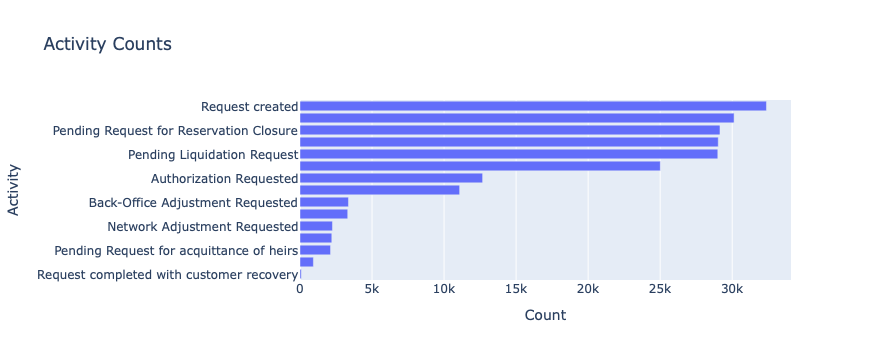

In [5]:
activity_plot = kairo.plot_activity_counts(stats)
activity_plot.show()

In [6]:
features = kairo.compute_features_intra(log, sliding_window_size=1)
features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
std_features = kairo.standardize(features, method="minmax")
std_features

,case:concept:name,time:timestamp,act_freqs:Authorization Requested,act_freqs:Back-Office Adjustment Requested,act_freqs:Evaluating Request (NO registered letter),act_freqs:Evaluating Request (WITH registered letter),act_freqs:Network Adjustment Requested,act_freqs:Pending Liquidation Request,act_freqs:Pending Request for Network Information,act_freqs:Pending Request for Reservation Closure,...,past_acts_1:Pending Liquidation Request,past_acts_1:Pending Request for Network Information,past_acts_1:Pending Request for Reservation Closure,past_acts_1:Pending Request for acquittance of heirs,past_acts_1:Request completed with account closure,past_acts_1:Request completed with customer recovery,past_acts_1:Request created,past_acts_1:Request deleted,past_acts_1:Service closure Request with BO responsibility,past_acts_1:Service closure Request with network responsibility
0,case_000000,2017-05-29 08:49:25+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_000000,2017-05-29 08:52:49+00:00,0.0,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,case_000000,2017-05-29 09:02:39+00:00,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_000000,2017-05-29 11:23:33+00:00,0.0,0.0,0.250000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,case_000000,2017-05-31 09:26:08+00:00,0.0,0.0,0.200000,0.0,0.4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212717,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
212718,case_032427,2019-03-06 15:01:31+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
212719,case_032428,2019-03-06 16:38:59+00:00,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


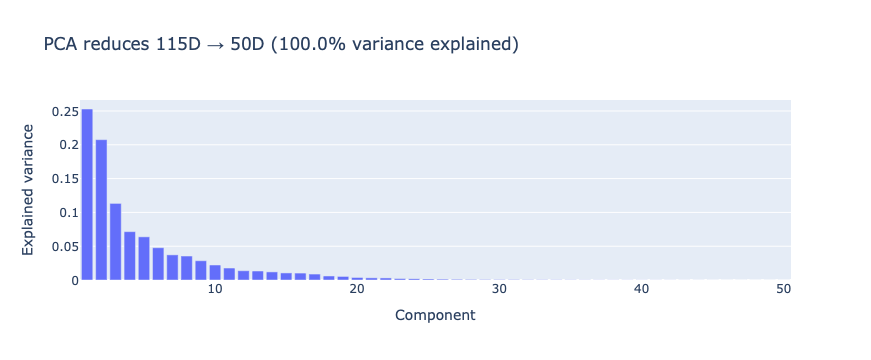

In [8]:
pca = kairo.compute_pca(std_features, num_components=50)
pca_plot = kairo.plot_pca_variances(pca)
pca_plot.show()
#pca

In [14]:
compressed_features = kairo.apply_pca(std_features, pca, cut_component=5)
compressed_features

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276
...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731


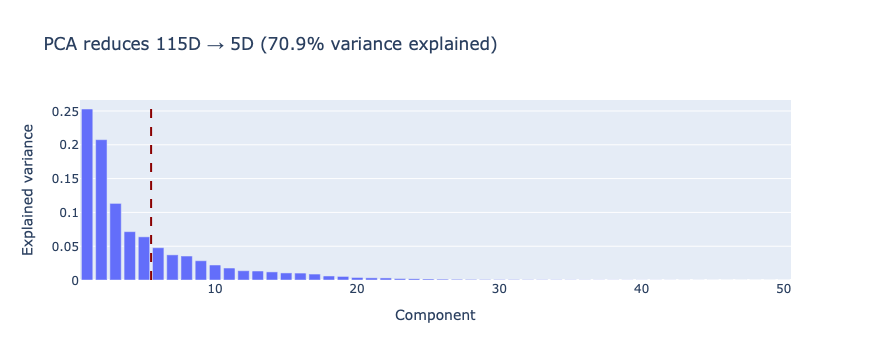

In [15]:
pca_plot_cut = kairo.plot_pca_variances(pca, cut_component=5)
pca_plot_cut.show()

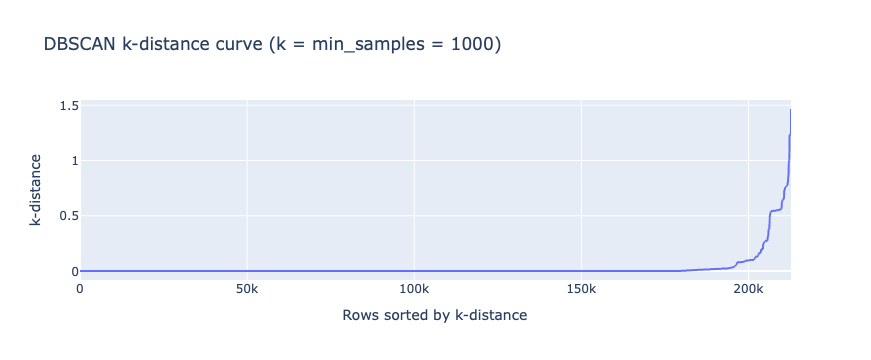

In [17]:
k_distance_plot = kairo.plot_dbscan_k_distance(compressed_features, min_samples=1000)
k_distance_plot.show()

In [12]:
dbscan = kairo.compute_dbscan(compressed_features, min_samples=12000, eps=0.4, distance="manhattan")
clusters = kairo.get_dbscan_clusters(compressed_features, dbscan)
clusters

,cluster
0,0
1,-1
2,-1
3,-1
4,-1
...,...
212716,-1
212717,0
212718,-1
212719,0


In [13]:
features_and_clusters = pd.concat([compressed_features, clusters], axis=1)
features_and_clusters

,case:concept:name,time:timestamp,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10,pc_11,pc_12,pc_13,cluster
0,case_000000,2017-05-29 08:49:25+00:00,-1.479990,-0.393453,-0.803889,-0.225304,-0.178530,0.327245,-0.501438,-0.215653,-0.267268,-0.115837,-0.059156,0.025088,-0.085787,0
1,case_000000,2017-05-29 08:52:49+00:00,-1.448551,0.484035,-0.116427,0.223079,0.198966,-0.509641,-0.131702,1.075069,0.750329,-0.464401,0.361062,-0.132697,-0.290555,-1
2,case_000000,2017-05-29 09:02:39+00:00,-1.057344,0.903372,0.711988,0.627993,0.498052,-0.749163,-0.222386,-0.145608,-0.694494,0.391446,0.597275,-0.118122,0.308936,-1
3,case_000000,2017-05-29 11:23:33+00:00,-0.501294,1.246955,1.285447,0.374433,0.154020,1.041550,0.080662,0.028620,0.184669,0.144771,-0.177328,0.085109,-0.113696,-1
4,case_000000,2017-05-31 09:26:08+00:00,-0.341880,1.248738,1.148390,-0.147339,-0.371276,0.088747,-0.141289,0.058532,-0.137768,-0.144888,0.056314,0.737973,-0.191332,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212716,case_032426,2019-03-06 14:59:39+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,-1
212717,case_032427,2019-03-06 15:01:31+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,0
212718,case_032427,2019-03-06 15:01:31+00:00,-1.200793,-0.270184,-0.661585,-0.035463,-0.046257,-0.267132,0.531438,0.570911,0.551734,-0.054681,-0.613459,0.875256,1.653444,-1
212719,case_032428,2019-03-06 16:38:59+00:00,-1.390102,-0.359147,-0.812277,-0.225946,-0.194731,0.323122,-0.469121,-0.200906,-0.239350,-0.088858,-0.059782,0.086458,0.030800,0


In [14]:
state_distances = kairo.get_dbscan_state_distances(dbscan)
state_distances

,0,1,2,3
0,0.000000,6.680222,8.036646,8.268103
1,6.680222,0.000000,7.302473,8.207181
2,8.036646,7.302473,0.000000,5.954902
3,8.268103,8.207181,5.954902,0.000000


In [15]:
state_freqs = kairo.get_dbscan_state_frequencies(features_and_clusters)
state_freqs

state
noise    142992
0         32377
1         12638
2         12457
3         12257
Name: events, dtype: int64

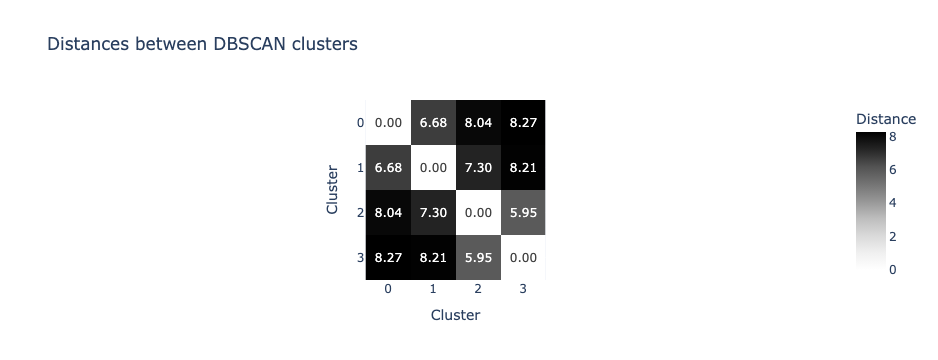

In [16]:
distances_plot = kairo.plot_dbscan_distances(state_distances)
distances_plot.show()

In [19]:
color_mapping = kairo.compute_dbscan_color_mapping(dbscan)

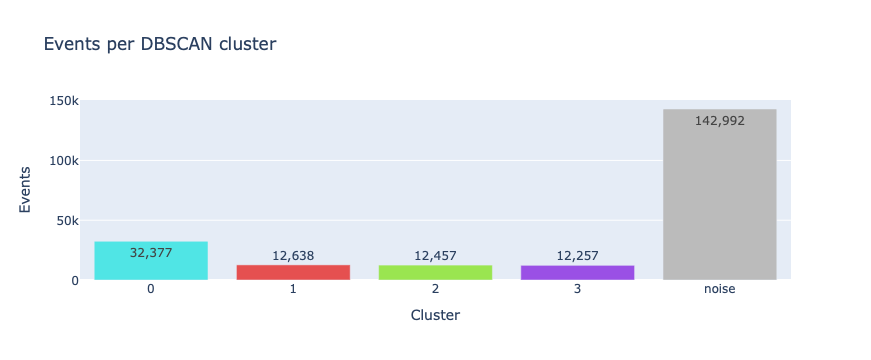

In [20]:
freqs_plot = kairo.plot_dbscan_frequencies(state_freqs, color_mapping)
freqs_plot.show()

In [21]:
case_trajectory = kairo.get_dbscan_case_trajectory(features_and_clusters, case_id="case_000001")
case_trajectory

,state,start,end,duration,events
0,0,2017-06-05 13:34:59+00:00,2017-06-05 14:20:48+00:00,0 days 00:45:49,1
1,1,2017-06-05 14:20:48+00:00,2017-06-12 08:28:02+00:00,6 days 18:07:14,1
2,2,2017-06-12 08:28:02+00:00,2017-06-14 10:11:14+00:00,2 days 01:43:12,1
3,3,2017-06-14 10:11:14+00:00,2018-02-09 13:13:06+00:00,240 days 03:01:52,1
4,noise,2018-02-09 13:13:06+00:00,2018-09-13 08:57:36+00:00,215 days 19:44:30,8


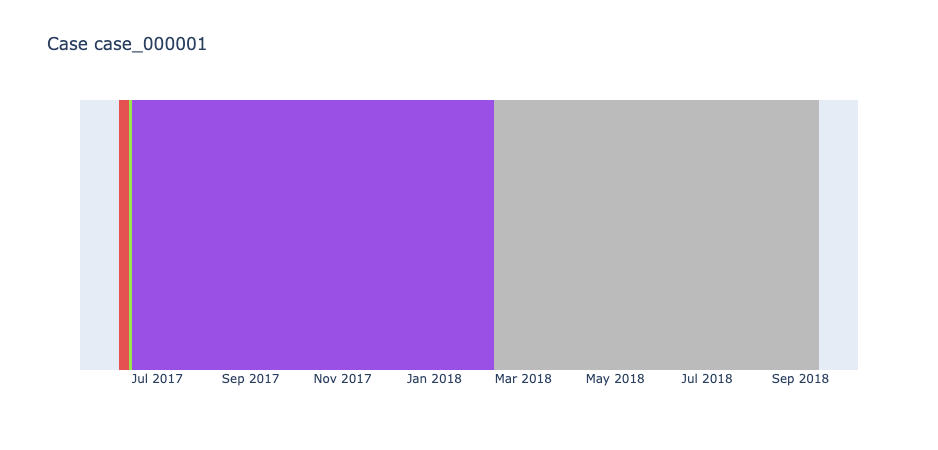

In [22]:
case_trajectory_plot = kairo.plot_dbscan_case_trajectory(case_trajectory, color_mapping, case_id="case_000001")
case_trajectory_plot

In [23]:
case_trajectories = kairo.get_dbscan_trajectories(features_and_clusters, max_cases=10)
case_trajectories

,case,state,start,end,duration,events
0,case_000000,0,2017-05-29 08:49:25+00:00,2017-05-29 08:52:49+00:00,0 days 00:03:24,1
1,case_000000,noise,2017-05-29 08:52:49+00:00,2017-06-15 03:04:22+00:00,16 days 18:11:33,8
2,case_000001,0,2017-06-05 13:34:59+00:00,2017-06-05 14:20:48+00:00,0 days 00:45:49,1
3,case_000001,1,2017-06-05 14:20:48+00:00,2017-06-12 08:28:02+00:00,6 days 18:07:14,1
4,case_000001,2,2017-06-12 08:28:02+00:00,2017-06-14 10:11:14+00:00,2 days 01:43:12,1
5,case_000001,3,2017-06-14 10:11:14+00:00,2018-02-09 13:13:06+00:00,240 days 03:01:52,1
6,case_000001,noise,2018-02-09 13:13:06+00:00,2018-09-13 08:57:36+00:00,215 days 19:44:30,8
7,case_000004,0,2017-07-12 10:34:30+00:00,2017-07-12 10:37:17+00:00,0 days 00:02:47,1
8,case_000004,noise,2017-07-12 10:37:17+00:00,2018-09-18 03:03:16+00:00,432 days 16:25:59,6
9,case_000005,0,2017-07-13 09:05:45+00:00,2018-02-09 11:24:06+00:00,211 days 02:18:21,1


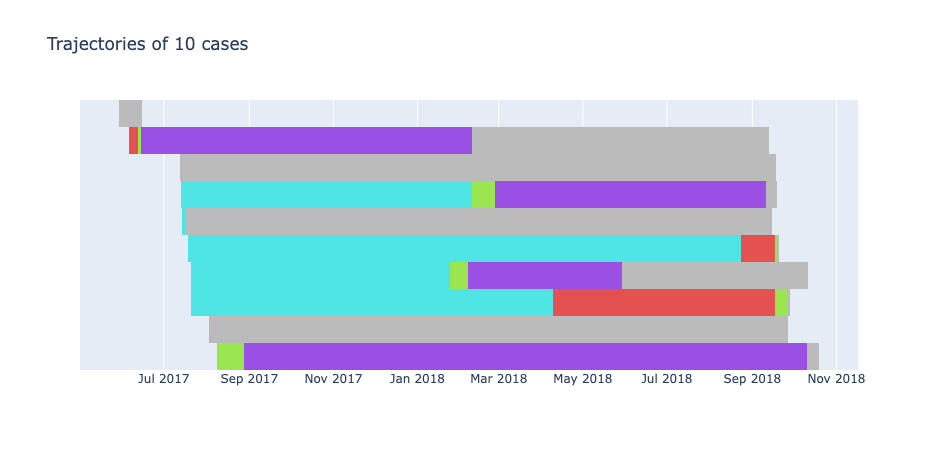

In [24]:
case_trajectories_plot = kairo.plot_dbscan_trajectories(case_trajectories, color_mapping)
case_trajectories_plot

In [25]:
freq_distributions = kairo.compute_state_distributions(features_and_clusters, window="30D")
freq_distributions

state,noise,0,1,2,3
window,,,,,
2017-05-24 00:00:00+00:00,0.615385,0.153846,0.076923,0.076923,0.076923
2017-06-23 00:00:00+00:00,0.250000,0.750000,0.000000,0.000000,0.000000
2017-07-23 00:00:00+00:00,0.200000,0.400000,0.200000,0.200000,0.000000
2017-08-22 00:00:00+00:00,0.055556,0.611111,0.111111,0.111111,0.111111
2017-09-21 00:00:00+00:00,0.161290,0.516129,0.161290,0.064516,0.096774
2017-10-21 00:00:00+00:00,0.400000,0.400000,0.142857,0.028571,0.028571
2017-11-20 00:00:00+00:00,0.279070,0.348837,0.139535,0.116279,0.116279
2017-12-20 00:00:00+00:00,0.140351,0.403509,0.245614,0.140351,0.070175
2018-01-19 00:00:00+00:00,0.216867,0.397590,0.192771,0.108434,0.084337


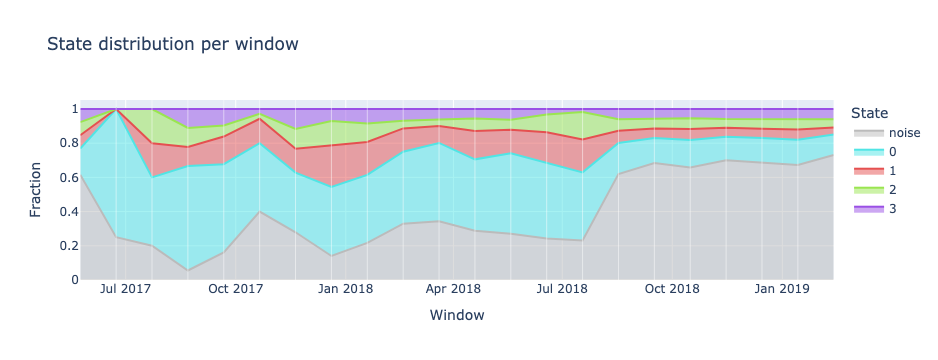

In [26]:
distributions_plot = kairo.plot_state_distributions(freq_distributions, color_mapping)
distributions_plot.show()

In [27]:
divergences = kairo.compute_divergences(freq_distributions)
divergences

,window,score
0,2017-05-24 00:00:00+00:00,NaN
1,2017-06-23 00:00:00+00:00,0.962893
2,2017-07-23 00:00:00+00:00,7.349459
3,2017-08-22 00:00:00+00:00,2.115664
4,2017-09-21 00:00:00+00:00,0.096389
5,2017-10-21 00:00:00+00:00,0.185881
6,2017-11-20 00:00:00+00:00,0.174925
7,2017-12-20 00:00:00+00:00,0.092133
8,2018-01-19 00:00:00+00:00,0.029320
9,2018-02-18 00:00:00+00:00,0.060176


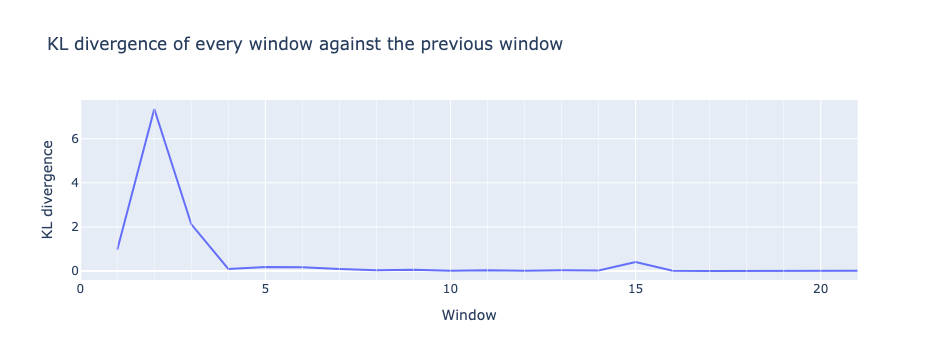

In [28]:
divergences_plot = kairo.plot_divergences(divergences)
divergences_plot.show()

In [29]:
abs_log_stats = kairo.abstract_log_stats(stats)
abs_log_stats

'Event log: 212,721 events of 32,429 cases, 15 activities and 654 resources, from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nThroughput time per case in days: min 0.00, mean 13.46, median 6.07, max 503.59.\nEvents per case: min 2, mean 6.6, median 7.0, max 23.\nEvents per activity: Request created (32,377), Service closure Request with BO responsibility (30,130), Pending Request for Reservation Closure (29,151), Request completed with account closure (29,031), Pending Liquidation Request (29,000), Service closure Request with network responsibility (25,009), Authorization Requested (12,675), Evaluating Request (NO registered letter) (11,080), Back-Office Adjustment Requested (3,363), Request deleted (3,312), Network Adjustment Requested (2,252), Evaluating Request (WITH registered letter) (2,207), Pending Request for acquittance of heirs (2,119), Pending Request for Network Information (929), Request completed with customer recovery (86)\nMost active resources: BOF (113,9

In [30]:
abs_features = kairo.abstract_features(features)
abs_features

'Intra-case feature matrix: 212,721 rows, one per event, each describing its case up to and including that event, with 115 feature columns.\nThe events belong to 32,429 cases.\nThey happened from 2017-05-29 08:49:25+00:00 to 2019-03-06 16:38:59+00:00.\nFeature groups:\n- act_freqs (share of every activity among the events of the case so far): 15 columns, mean value 0.067, non-zero in 26.4% of the cells, highest column means act_freqs:Request created = 0.378, act_freqs:Service closure Request with network responsibility = 0.162, act_freqs:Service closure Request with BO responsibility = 0.118\n- df_counts (how often every directly-follows pair happened in the case so far): 54 columns, mean value 0.056, non-zero in 5.6% of the cells, highest column means df_counts:Service closure Request with BO responsibility -> Pending Request for Reservation Closure = 0.419, df_counts:Request created -> Service closure Request with network responsibility = 0.387, df_counts:Service closure Request with

In [31]:
abs_pca = kairo.abstract_pca(pca, cut_component=13)
abs_pca

'PCA fitted 50 components on 115 feature columns. The cut keeps the first 13, which explain 92.5% of the variance.\nExplained variance per component: pc_1 25.3%, pc_2 20.8%, pc_3 11.3%, pc_4 7.2%, pc_5 6.4%, pc_6 4.8%, pc_7 3.7%, pc_8 3.5%, pc_9 2.8%, pc_10 2.2%, pc_11 1.8%, pc_12 1.4%, pc_13 1.3%, pc_14 1.2%, pc_15 1.0%, pc_16 1.0%, pc_17 0.9%, pc_18 0.6%, pc_19 0.5%, pc_20 0.4%, pc_21 0.3%, pc_22 0.3%, pc_23 0.2%, pc_24 0.2%, pc_25 0.1%, pc_26 0.1%, pc_27 0.1%, pc_28 0.1%, pc_29 0.1%, pc_30 0.1%, pc_31 0.0%, pc_32 0.0%, pc_33 0.0%, pc_34 0.0%, pc_35 0.0%, pc_36 0.0%, pc_37 0.0%, pc_38 0.0%, pc_39 0.0%, pc_40 0.0%, pc_41 0.0%, pc_42 0.0%, pc_43 0.0%, pc_44 0.0%, pc_45 0.0%, pc_46 0.0%, pc_47 0.0%, pc_48 0.0%, pc_49 0.0%, pc_50 0.0%\nFeatures with the strongest loadings on every kept component:\n- pc_1: act_set:Pending Request for Reservation Closure (+0.34), act_set:Service closure Request with BO responsibility (+0.34), act_set:Pending Liquidation Request (+0.30), df_counts:Pending R

In [32]:
abs_states = kairo.abstract_states(state_freqs, state_distances, color_mapping)
abs_states

'5 states occur among the 212,721 events. Events per state:\n- noise: 142,992 events (67.2%)\n- 0: 32,377 events (15.2%)\n- 1: 12,638 events (5.9%)\n- 2: 12,457 events (5.9%)\n- 3: 12,257 events (5.8%)\nNearest and farthest other state for every state, by the distance between them:\n- 0: nearest 1 (6.68), farthest 3 (8.27)\n- 1: nearest 0 (6.68), farthest 3 (8.21)\n- 2: nearest 3 (5.95), farthest 0 (8.04)\n- 3: nearest 2 (5.95), farthest 0 (8.27)\nColors of the states in the plots:\n- 0: #50e5e5 (cyan)\n- 1: #e55050 (red)\n- 2: #9ae550 (green)\n- 3: #9a50e5 (purple)\n- noise: #bbbbbb (grey)'

In [33]:
abs_case_trajectory = kairo.abstract_case_trajectory(case_trajectory, "case_000001")
abs_case_trajectory

'Trajectory of case case_000001, one line per visit of a state, in order:\n- 0 from 2017-06-05 13:34:59+00:00 to 2017-06-05 14:20:48+00:00 (0 days 00:45:49, 1 events)\n- 1 from 2017-06-05 14:20:48+00:00 to 2017-06-12 08:28:02+00:00 (6 days 18:07:14, 1 events)\n- 2 from 2017-06-12 08:28:02+00:00 to 2017-06-14 10:11:14+00:00 (2 days 01:43:12, 1 events)\n- 3 from 2017-06-14 10:11:14+00:00 to 2018-02-09 13:13:06+00:00 (240 days 03:01:52, 1 events)\n- noise from 2018-02-09 13:13:06+00:00 to 2018-09-13 08:57:36+00:00 (215 days 19:44:30, 8 events)'

In [34]:
abs_case_trajectories = kairo.abstract_case_trajectories(case_trajectories)
abs_case_trajectories

'Trajectories of 10 cases, from 2017-05-29 08:49:25+00:00 to 2018-10-19 09:50:35+00:00. A case visits 3.8 states on average and lasts 432 days 17:13:14 (median).\nThe most common paths through the states, with how many cases took them:\n- 0 -> 1 -> 2 -> 3 -> noise: 6 cases (60.0%)\n- 0 -> noise: 4 cases (40.0%)\nThe most common moves from one state to the next:\n- 0 -> 1: 6 times\n- 1 -> 2: 6 times\n- 2 -> 3: 6 times\n- 3 -> noise: 6 times\n- 0 -> noise: 4 times\nStates the cases start in: 0 (10)\nStates the cases end in: noise (10)'

In [35]:
abs_distributions = kairo.abstract_distributions(freq_distributions)
abs_distributions

'State distribution over 22 calendar windows from 2017-05-24 00:00:00+00:00 to 2019-02-13 00:00:00+00:00: the share of every state among the events of each window.\nShare of every state over the windows, mean, lowest and highest:\n- noise: mean 39.9%, lowest 5.6% in the window starting 2017-08-22 00:00:00+00:00, highest 73.1% in the window starting 2019-02-13 00:00:00+00:00\n- 0: mean 34.7%, lowest 12.0% in the window starting 2019-02-13 00:00:00+00:00, highest 75.0% in the window starting 2017-06-23 00:00:00+00:00\n- 1: mean 11.7%, lowest 0.0% in the window starting 2017-06-23 00:00:00+00:00, highest 24.6% in the window starting 2017-12-20 00:00:00+00:00\n- 2: mean 7.9%, lowest 0.0% in the window starting 2017-06-23 00:00:00+00:00, highest 20.0% in the window starting 2017-07-23 00:00:00+00:00\n- 3: mean 5.9%, lowest 0.0% in the window starting 2017-06-23 00:00:00+00:00, highest 11.6% in the window starting 2017-11-20 00:00:00+00:00\nThe largest changes from one window to the next, wi

In [36]:
abs_divergences = kairo.abstract_divergences(divergences, divergence="kl", reference="recent")
abs_divergences

'Drift signal: the KL divergence between the state distribution of every calendar window and the mean of the 5 windows before it, over 22 windows from 2017-05-24 00:00:00+00:00 to 2019-02-13 00:00:00+00:00. The windows are numbered from 0 as in the plot.\nScores: median 0.032, mean 0.553, highest 7.349.\nThe windows with the highest scores:\n- window 2, starting 2017-07-23 00:00:00+00:00: 7.349\n- window 3, starting 2017-08-22 00:00:00+00:00: 2.116\n- window 1, starting 2017-06-23 00:00:00+00:00: 0.963\n- window 15, starting 2018-08-17 00:00:00+00:00: 0.413\n- window 5, starting 2017-10-21 00:00:00+00:00: 0.186'

In [37]:
inp_tokens = kairo.count_input_tokens(provider="custom",
                                system_prompt=kairo.DEFAULT_SYSTEM_PROMPT, 
                                prompts=[abs_log_stats + abs_features + 
                                    abs_pca + abs_states + abs_case_trajectory + abs_case_trajectories
                                    + abs_distributions + abs_divergences + 
                                    "Analyze and summarize the given information. Do not use markdown format, just raw text"],
                                plots=[activity_plot, pca_plot_cut, distances_plot, freqs_plot,
                                            case_trajectory_plot, case_trajectories_plot,
                                            distributions_plot, divergences_plot])

num_tokens, messages = inp_tokens
num_tokens

7912

In [38]:
llm = kairo.LLMConnector(
    provider="custom",
    #api_key=os.environ["ANTHROPIC_API_KEY"],
    model="Qwen/Qwen3-VL-32B-Instruct",
    base_url="http://137.226.117.70:8000/v1"
)

response = llm.call(messages=messages, max_tokens=64000)


In [39]:
out_tokens = kairo.count_output_tokens("custom", response)
out_tokens

760

In [40]:
answer = kairo.get_response_text(response)
print(answer)

The event log contains 212,721 events from 32,429 cases, spanning from May 2017 to March 2019. The process involves 15 activities, with "Request created" being the most frequent, followed by "Service closure Request with BO responsibility" and "Pending Request for Reservation Closure". The average case takes about 13 days to complete, with a median of 6 days, and involves around 7 events.

The intra-case feature matrix has 115 columns, capturing various aspects of a case’s state up to each event, including activity frequencies, directly-follows counts, and past activity indicators. PCA reduced this to 13 components, explaining 92.5% of the variance. The first few components are heavily influenced by features related to specific activities like "Pending Request for Reservation Closure", "Evaluating Request", and "Request completed with account closure", suggesting these are key discriminators in the state space.

Clustering with DBSCAN identified 5 states: 4 clusters (0, 1, 2, 3) and a 